# Transformaciones y Feature Engineering Avanzado

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/04_transformaciones_y_fe_avanzado.ipynb)

## Objetivos


- Comprender cómo las distribuciones asimétricas (*skewed*) degradan el rendimiento de los modelos y cómo corregirlas mediante transformaciones matemáticas (Logaritmo, Box-Cox).
- Aprender a crear características polinómicas e interacciones para capturar relaciones complejas.
- Desarrollar intuición geométrica: cómo "doblar el espacio" matemático para que problemas no lineales se vuelvan linealmente separables.
- Entender por qué la correlación lineal falla en estructuras geométricas concéntricas o bimodales.



## Prerrequisitos


- [Análisis de Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb).
- Conocimientos básicos de geometría analítica (ecuación de la circunferencia, parábolas).

---


## Configuración del Entorno


In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

from utils.plots import setup_plot_style
setup_plot_style()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer, PolynomialFeatures
from sklearn.datasets import make_circles

import warnings
warnings.filterwarnings('ignore')

## Introducción Teórica



Hasta ahora limpiamos datos y analizamos sus correlaciones lineales. Pero, ¿qué pasa cuando la realidad no es una línea recta?

Muchos algoritmos clásicos (como la Regresión Lineal, Regresión Logística o SVM lineal) son, en esencia, trazadores de líneas rectas o planos (*lo vemos en detalle más adelante, idea básica por el momento*). Si nuestros datos tienen forma de curva, espiral o están severamente concentrados en un extremo, el modelo fallará.

En lugar de saltar inmediatamente a un modelo ultra-complejo (como una Red Neuronal profunda), un buen ingeniero de IA primero intenta **transformar los datos**. Si aplicamos la función matemática correcta a nuestras variables, podemos "desdoblar" el espacio, haciendo que un problema complejo se vuelva trivial para un algoritmo simple.

## 1. El Problema de la Asimetría (Skewness)


Imaginemos que analizamos el precio de las propiedades en una ciudad. La mayoría de las casas cuestan entre \$100k y \$300k. Pero hay unas pocas mansiones que cuestan \$5 millones.

Esto genera una distribución con **Asimetría Positiva** (una "cola" larga hacia la derecha). Los algoritmos basados en el error cuadrático (como la regresión lineal) se volverán locos intentando minimizar el error de esas mansiones, arruinando las predicciones para el 99% de las casas normales.

Vamos a simular este escenario:

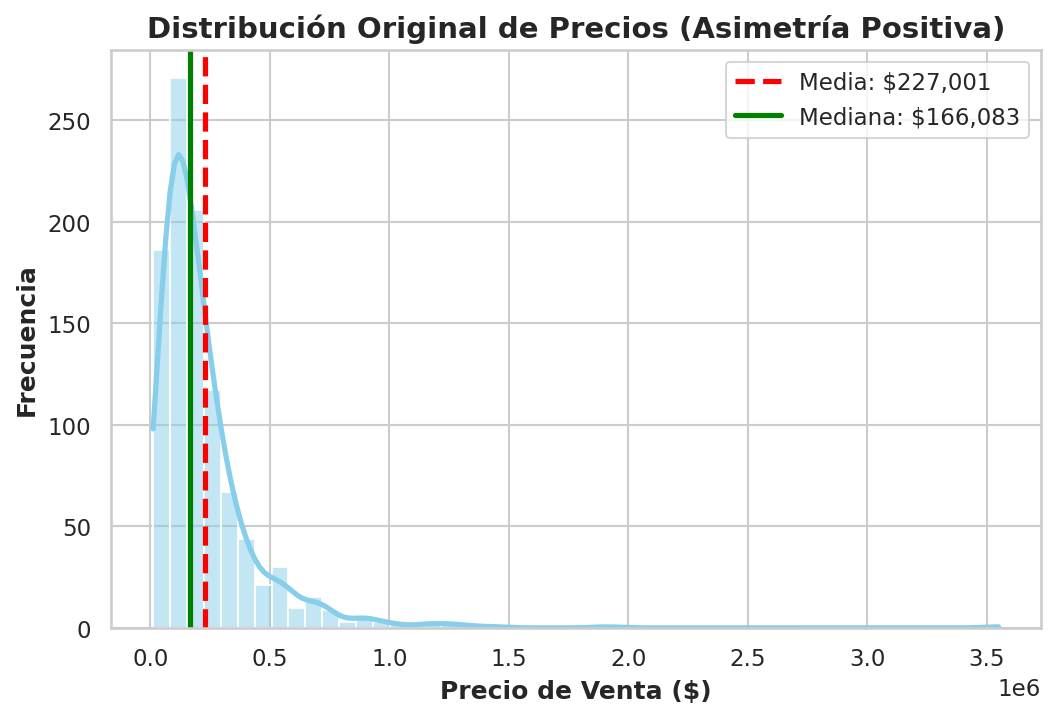

In [3]:
# Generamos precios de propiedades con distribución log-normal (típico en economía)
np.random.seed(42)
precios = np.random.lognormal(mean=12, sigma=0.8, size=1000)

df_precios = pd.DataFrame({'Precio_Venta': precios})

# Calculamos Media y Mediana
media = df_precios['Precio_Venta'].mean()
mediana = df_precios['Precio_Venta'].median()

plt.figure(figsize=(8, 5))
sns.histplot(df_precios['Precio_Venta'], bins=50, kde=True, color='skyblue')
plt.axvline(media, color='red', linestyle='--', label=f'Media: ${media:,.0f}')
plt.axvline(mediana, color='green', linestyle='-', label=f'Mediana: ${mediana:,.0f}')
plt.title("Distribución Original de Precios (Asimetría Positiva)")
plt.xlabel("Precio de Venta ($)")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()


**Análisis de Ingeniería:**

Observar la enorme diferencia entre la media y la mediana. La media está siendo arrastrada por los valores extremos. Si entrenamos un modelo con esto, los gradientes matemáticos serán inestables.

### La Solución: Transformación Logarítmica



Aplicar un logaritmo natural ($ln(x)$) comprime los números grandes mucho más que los números pequeños, "acercando" esa cola larga hacia el centro y normalizando la campana.

$$ X_{transformado} = \ln(X + 1) $$

*Nota: Sumamos 1 (`log1p` en numpy) para evitar el error matemático de calcular el logaritmo de cero, en caso de que haya valores nulos en la variable.*



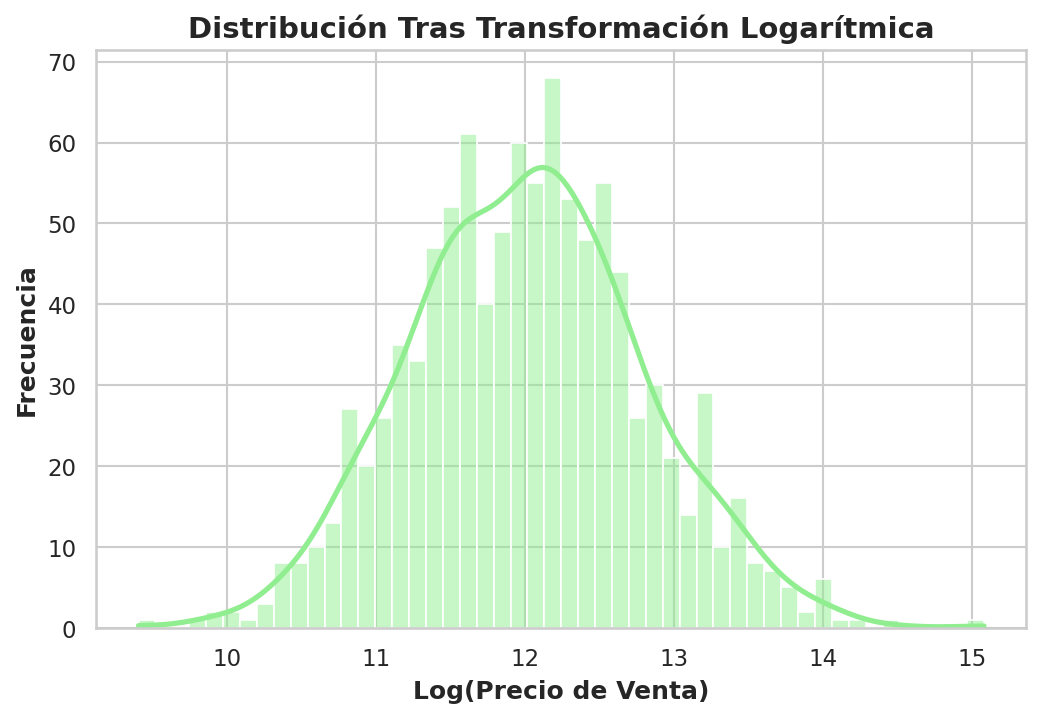

In [4]:
# Aplicamos logaritmo natural (log1p)
df_precios['Precio_Log'] = np.log1p(df_precios['Precio_Venta'])

plt.figure(figsize=(8, 5))
sns.histplot(df_precios['Precio_Log'], bins=50, kde=True, color='lightgreen')
plt.title("Distribución Tras Transformación Logarítmica")
plt.xlabel("Log(Precio de Venta)")
plt.ylabel("Frecuencia")
plt.show()


¡Magia! Ahora tenemos una distribución casi perfectamente normal (Gaussiana). Los algoritmos lineales amarán esta variable.

> ⚠️ **Advertencia:** Si se opta por transformar la variable objetivo (*target*) para entrenar un modelo de regresión, recordar (**IMPORTANTE**) que las predicciones del modelo estarán en **escala logarítmica**. Se deberá aplicar la función inversa (exponencial, `np.expm1`) a las predicciones para presentarlas al cliente en dólares reales (o la unidad/escala original de la variable).

*(Para transformaciones más automáticas que manejan tanto asimetría positiva como negativa, se utiliza `PowerTransformer` de Scikit-Learn, que aplica los métodos de Box-Cox o Yeo-Johnson).*


## 2. Doblando el Espacio: El Problema del Anillo



A veces, el problema no es la distribución de una variable aislada, sino **cómo interactúan dos variables entre sí**.

Imaginemos ahora que, estamos analizando un proceso químico. Si la Temperatura ($X_1$) y la Presión ($X_2$) están ambas en un rango medio, la reacción es estable (Clase 0). Si cualquiera de las dos es muy alta o muy baja, el reactor explota (Clase 1).

Vamos a generar este dataset sintético:

Correlación de Pearson con el Target:


,Target
X1,-0.003109
X2,0.000737
Target,1.000000


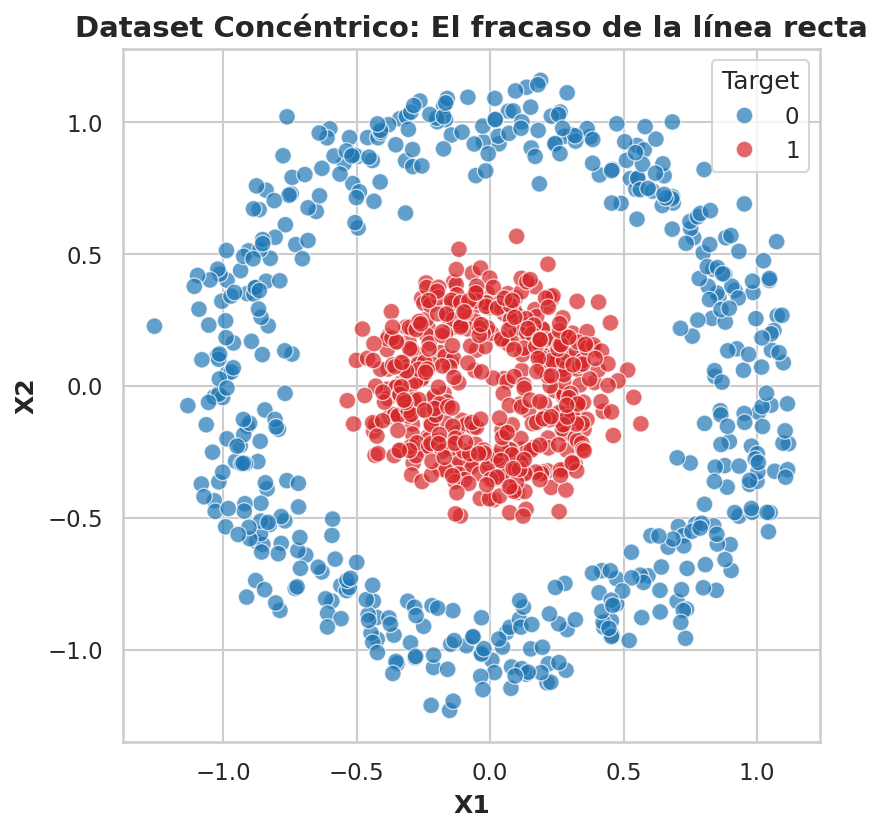

In [5]:
# Generamos un dataset concéntrico (un anillo dentro de otro)
X, y = make_circles(n_samples=1000, factor=0.3, noise=0.1, random_state=42)
df_anillo = pd.DataFrame({'X1': X[:, 0], 'X2': X[:, 1], 'Target': y})

# Veamos la correlación lineal
print("Correlación de Pearson con el Target:")
display(df_anillo.corr()[['Target']])

# Visualizamos el problema
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df_anillo, x='X1', y='X2', hue='Target', palette=['#1f77b4', '#d62728'], alpha=0.7)
plt.title("Dataset Concéntrico: El fracaso de la línea recta")
plt.show()

**El Engaño de la Correlación:**

Si se mira la tabla de correlación, tanto $X_1$ como $X_2$ tienen una correlación de **~0.00** con el Target. Un analista inexperto diría: *"Estas variables son ruido, hay que eliminarlas"*.

Sin embargo, al ver el gráfico, es evidente que la posición de $X_1$ y $X_2$ determina **perfectamente** la clase. El problema es que ninguna línea recta puede separar el punto azul central del anillo rojo exterior.

### La Solución Geométrica: Distancia al Origen



¿Qué diferencia a los puntos azules de los rojos? Su distancia al centro (0,0).
Recordemos el Teorema de Pitágoras o la ecuación de la circunferencia. La distancia al cuadrado de un punto al origen es:

$$ Distancia^2 = X_1^2 + X_2^2 $$

Vamos a crear esta nueva característica (*Feature Engineering* puro) y ver qué sucede.



Nueva Correlación con el Target:


,Distancia_Cuadrada,Target
Distancia_Cuadrada,1.00000,-0.95104
Target,-0.95104,1.00000


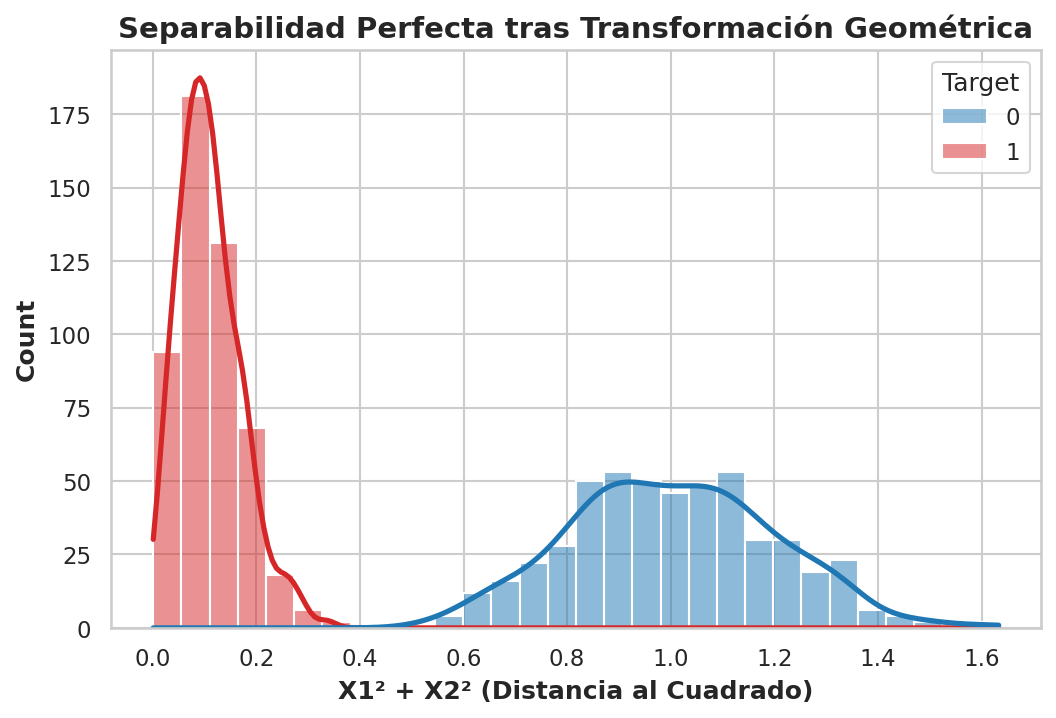

In [6]:
# Elevamos al cuadrado y sumamos
df_anillo['Distancia_Cuadrada'] = df_anillo['X1']**2 + df_anillo['X2']**2

# Veamos la nueva correlación
print("Nueva Correlación con el Target:")
display(df_anillo[['Distancia_Cuadrada', 'Target']].corr())

# Visualizamos la separabilidad
plt.figure(figsize=(8, 5))
sns.histplot(data=df_anillo, x='Distancia_Cuadrada', hue='Target', palette=['#1f77b4', '#d62728'], bins=30, kde=True)
plt.title("Separabilidad Perfecta tras Transformación Geométrica")
plt.xlabel("X1² + X2² (Distancia al Cuadrado)")
plt.show()


**¡Boom!** La correlación pasó de 0.00 a **-0.95**.

Al elevar las variables al cuadrado, hemos proyectado un problema 2D plano hacia un espacio 3D (un paraboloide). En ese nuevo espacio, la clase azul está en el fondo del "cuenco" y la clase roja en los bordes altos. Ahora, un simple modelo lineal puede trazar un plano horizontal y separar las clases con un 100% de precisión.


> *Álgebra y Cálculo... resulta que sirven entonces.*


## 3. Automatizando Interacciones: PolynomialFeatures



En la vida real, no siempre es tan obvio que debemos elevar al cuadrado. A veces la relación oculta es una multiplicación entre variables ($X_1 \cdot X_2$), conocida como **Interacción**.

Por ejemplo: El `Precio` de un terreno no depende solo del `Ancho` o del `Largo` por separado, sino de su multiplicación (`Área = Ancho * Largo`).

Scikit-Learn nos provee una herramienta para generar todas estas combinaciones automáticamente:

In [7]:
# Tomamos solo 3 muestras de nuestro dataset para ver qué hace el algoritmo
X_sample = df_anillo[['X1', 'X2']].head(3)

# Generamos polinomios de grado 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_sample)

# Mostramos los nombres de las nuevas columnas generadas
nombres_columnas = poly.get_feature_names_out(['X1', 'X2'])
df_poly_ejemplo = pd.DataFrame(X_poly, columns=nombres_columnas)

print("Dataset Original (2 variables):")
display(X_sample)
print("\nDataset Expandido con PolynomialFeatures (5 variables):")
display(df_poly_ejemplo)

Dataset Original (2 variables):


,X1,X2
0,0.229418,0.154278
1,-0.185373,0.125955
2,-0.369968,0.280985



Dataset Expandido con PolynomialFeatures (5 variables):


,X1,X2,X1^2,X1 X2,X2^2
0,0.229418,0.154278,0.052632,0.035394,0.023802
1,-0.185373,0.125955,0.034363,-0.023349,0.015865
2,-0.369968,0.280985,0.136877,-0.103955,0.078952



Como vemos, el algoritmo automáticamente creó:
- Las variables originales ($X_1$, $X_2$).
- Las variables al cuadrado ($X_1^2$, $X_2^2$).
- La interacción entre ellas ($X_1 \cdot X_2$).

> ⚠️ **El Peligro de la Explosión Combinatoria:** Si se tienen 100 variables originales y se aplica un polinomio de grado 3, se producen más de **170.000 nuevas columnas**. Esto destruirá la memoria de tu computadora (naaa, colapsa la RAM solamente, como mucho... Colab te cierra la sesión y toca comenzar de nuevo) y causará un sobreajuste masivo (*Maldición de la Dimensionalidad*). Usar esta técnica con mucha precaución y preferiblemente después de haber seleccionado solo las variables más importantes.

## Resultados y Discusión



En este notebook aprendimos que los datos crudos rara vez están listos para ser modelados directamente.
1. Las distribuciones asimétricas (como el dinero o el tiempo) engañan a los promedios y a los algoritmos; aplicar logaritmos estabiliza la varianza.
2. La correlación lineal es ciega a la geometría. Dos variables pueden tener correlación cero con el target, pero al combinarlas matemáticamente (ej. $X_1^2 + X_2^2$), revelan el patrón subyacente que resuelve el problema.

## Conexiones y Próximos Pasos


- ➡️ **Siguiente:** Ya sabemos cómo transformar variables y crear nuevas. Pero, ¿qué pasa si nuestras variables tienen escalas completamente distintas (ej. una va de 0 a 1 y otra de 0 a 1,000,000)? Lo resolveremos en [Escalado y Geometría de Datos](05_escalado_y_geometria.ipynb).
- 🔄 **Relacionado:** La creación masiva de variables polinómicas nos obliga a entender la compresión de datos. Repasa esto en [Reducción de Dimensionalidad (PCA)](06_reduccion_dimensionalidad_pca.ipynb).



## Referencias


1. [Documentación de PowerTransformer (Scikit-Learn)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html)
2. [Documentación de PolynomialFeatures (Scikit-Learn)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)

---


## Entorno de Ejecución


In [8]:
from utils.environment import environment_table
environment_table(include_all=False)

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
